# <a href="https://girafe.ai/" target="_blank" rel="noopener noreferrer"><img src="https://raw.githubusercontent.com/girafe-ai/ml-course/7096a5df4cada5ee651be1e3215c2f7fb8a7e0bf/logo_margin.svg" alt="girafe-ai logo" width="150px" align="left"></a> [ml-basic course](https://github.com/girafe-ai/ml-course) <a class="tocSkip">

# Lab assignment №1, part 2

This lab assignment consists of several parts.

In this part you will work with SVM algorithm and it's kernels.

Several comments:
* Don't hesitate to ask questions in a chat, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

##  1. SVM and kernels

Kernels concept get adopted in variety of ML algorithms (e.g. Kernel PCA, Gaussian Processes, kNN, ...).

So in this task you are to examine kernels for SVM algorithm applied to rather simple artificial datasets.

To make it clear: we will work with the classification problem through the whole notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Let's generate our dataset and take a look on it.

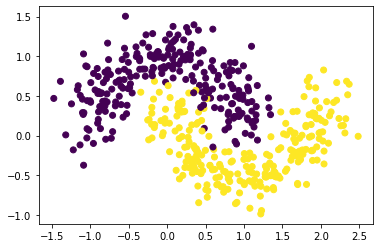

In [2]:
moons_points, moons_labels = make_moons(n_samples=500, noise=0.2, random_state=42)
plt.scatter(moons_points[:, 0], moons_points[:, 1], c=moons_labels)

## 1.1 Pure models

First let's try to solve this case with good old Logistic Regression and simple (linear kernel) SVM classifier.

* train LR and SVM classifiers (choose params by hand, no CV or intensive grid search neeeded)
* plot their decision regions
* calculate preffered classification metrics.
* describe results in one-two sentences.

_Tip:_ to plot classifiers decisions you colud use either sklearn examples ([this](https://scikit-learn.org/stable/auto_examples/neural_networks/plot_mlp_alpha.html#sphx-glr-auto-examples-neural-networks-plot-mlp-alpha-py) or any other) and plot with matplotlib yourself or use [mlxtend](https://github.com/rasbt/mlxtend) package (see their examples for details)

_Pro Tip:_ wirte function `plot_decisions` taking a dataset and an estimator and plotting the results cause you want to use it several times below

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from mlxtend.plotting import plot_decision_regions

def print_metrics(name, est, X_test, y_test):
    y_pred = est.predict(X_test)
    print(f"=== {name} ===")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score : {f1_score(y_test, y_pred, average='macro'):.4f}")
    print()
    
def plot_decisions(X, y, est, title):
    plt.figure(figsize=(6,5))
    plot_decision_regions(X=X, y=y.astype(int), clf=est, legend=2)
    plt.title(title)
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.tight_layout()
    plt.show()

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split


lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=500, random_state=42)
svm = SVC(kernel='linear', C=1.0, random_state=42)

X, y = moons_points, moons_labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr.fit(X_train, y_train)
svm.fit(X_train, y_train)

print_metrics("LogReg (linear)", lr, X_test, y_test)
print_metrics("SVM (linear)", svm, X_test, y_test)

=== LogReg (linear) ===
Accuracy : 0.8600
Precision: 0.8615
Recall   : 0.8686
F1-score : 0.8595

=== SVM (linear) ===
Accuracy : 0.8500
Precision: 0.8534
Recall   : 0.8599
F1-score : 0.8496



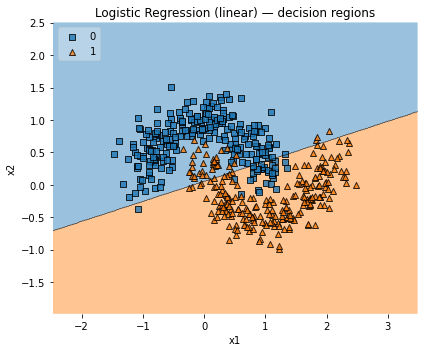

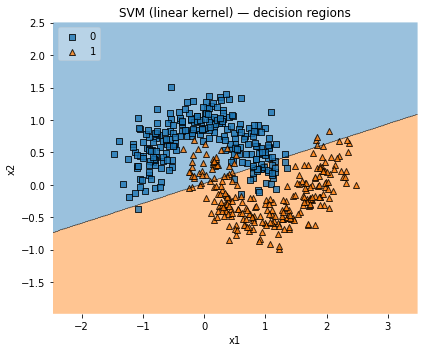

In [5]:
plot_decisions(X, y, lr,  "Logistic Regression (linear) — decision regions")
plot_decisions(X, y, svm, "SVM (linear kernel) — decision regions")

## 1.2 Kernel tirck

Now use different kernels (`poly`, `rbf`, `sigmoid`) on SVC to get better results. Play `degree` parameter and others.

For each kernel
* estimate optimal params (with a few manual trials)
* plot decision regions
* calculate metrics you've chosen eariler

=== SVM (poly d=3, C=5, coef0=1) ===
Accuracy : 0.9800
Precision: 0.9778
Recall   : 0.9825
F1-score : 0.9797



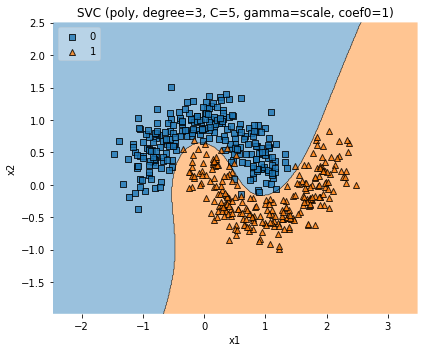

In [6]:
svm_poly = SVC(kernel="poly", degree=3, C=5.0, gamma="scale", coef0=1.0, random_state=42)
svm_poly.fit(X_train, y_train)
print_metrics("SVM (poly d=3, C=5, coef0=1)", svm_poly, X_test, y_test)
plot_decisions(X, y, svm_poly, "SVC (poly, degree=3, C=5, gamma=scale, coef0=1)")

=== SVM (rbf, C=5, gamma=0.8) ===
Accuracy : 0.9700
Precision: 0.9674
Recall   : 0.9737
F1-score : 0.9696



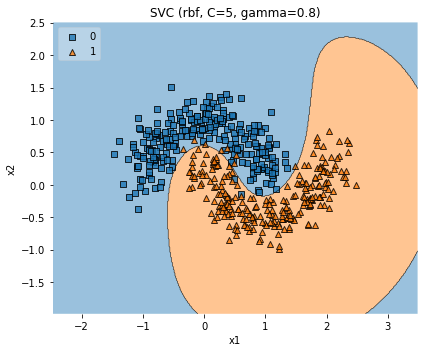

In [7]:
svm_rbf = SVC(kernel="rbf", C=5.0, gamma=0.8, random_state=42)
svm_rbf.fit(X_train, y_train)
print_metrics("SVM (rbf, C=5, gamma=0.8)", svm_rbf, X_test, y_test)
plot_decisions(X, y, svm_rbf, "SVC (rbf, C=5, gamma=0.8)")

=== SVM (sigmoid, C=3, gamma=0.8, coef0=0) ===
Accuracy : 0.6600
Precision: 0.6648
Recall   : 0.6675
F1-score : 0.6595



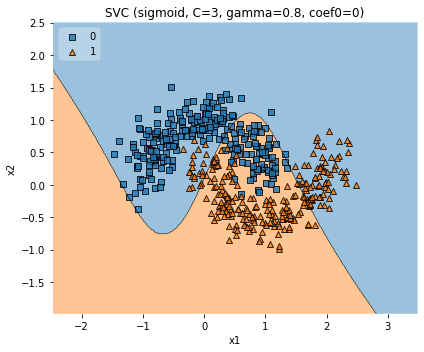

In [8]:
svm_sig = SVC(kernel="sigmoid", C=3.0, gamma=0.8, coef0=0.0, random_state=42)
svm_sig.fit(X_train, y_train)
print_metrics("SVM (sigmoid, C=3, gamma=0.8, coef0=0)", svm_sig, X_test, y_test)
plot_decisions(X, y, svm_sig, "SVC (sigmoid, C=3, gamma=0.8, coef0=0)")

Write couple of sentences on:

* What have happenned with classification quality?
* How did decision border changed for each kernel?
* What `degree` have you chosen and why?

* Качество моделей заметно улучшилось после использования *kernel trick* и перехода к нелинейным ядрам. `Poly` и `RBF` показали себя лучше всего на данном датасете. Сигмоидальное ядро сработало хуже из-за чувствительности к параметрам.
* Линейные модели строили одну разделяющую прямую, явно недообучаясь. Полиномиальное ядро добавило гладкую кривизну, RBF ядро сформировало точно повторяющую структуру выборки границу, а сигмоидальное ядро дало неточную *S-образную* границу.
* Было выбрана степень `degree = 3`, так как это минимальная степень, которая даёт достаточную нелинейность для моделирования формы датасета. Большая степень привела бы к переобучению и осциляциям на краях.

## 1.3 Simpler solution (of a kind)
What is we could use Logisitc Regression to successfully solve this task?

Feature generation is a thing to help here. Different techniques of feature generation are used in real life, couple of them will be covered in additional lectures.

In particular case simple [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) are able to save the day.

Generate the set of new features, train LR on it, plot decision regions, calculate metric.

* Comare SVM's results with this solution (quality, borders type)
* What degree of PolynomialFeatures have you used? Compare with same SVM kernel parameter.

=== LR + PolyFeatures (deg=3) ===
Accuracy : 0.9500
Precision: 0.9479
Recall   : 0.9561
F1-score : 0.9496



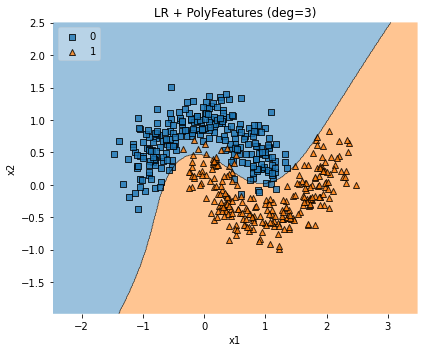

In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly_degree = 3
lr_poly = make_pipeline(
    PolynomialFeatures(poly_degree),
    LogisticRegression(C=1.0, solver='lbfgs', max_iter=500, random_state=42)
)
lr_poly.fit(X_train, y_train)

print_metrics(f"LR + PolyFeatures (deg={poly_degree})", lr_poly, X_test, y_test)
plot_decisions(X, y, lr_poly, f"LR + PolyFeatures (deg={poly_degree})")

* Граница, полученная применением логистической регрессии с полиномиальными признаками, смогла уловить форму датасета и показала себя очень похоже на границу, полученную применением SVM с полиномиальным ядром.
* В качестве степени полиномиальных признаков использовалась `poly_degree=3`, точно такая же степень как и при использвании SVM. Причина аналогичная $-$ такая степень уже позволяет схватить форму датасета, но ещё не подвержена переобучению.

## 1.4 Harder problem

Let's make this task a bit more challenging via upgrading dataset:

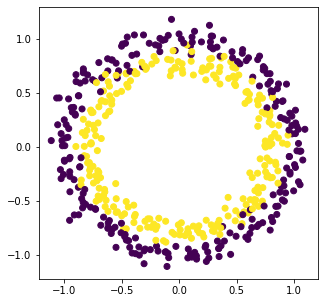

In [10]:
from sklearn.datasets import make_circles


circles_points, circles_labels = make_circles(n_samples=500, noise=0.06, random_state=42)

plt.figure(figsize=(5, 5))
plt.scatter(circles_points[:, 0], circles_points[:, 1], c=circles_labels)

And even more:

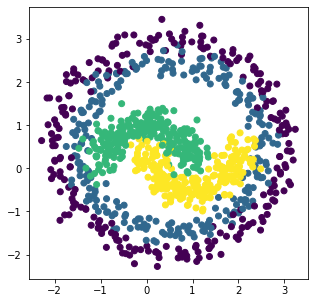

In [11]:
points = np.vstack((circles_points * 2.5 + 0.5, moons_points))
labels = np.hstack((circles_labels, moons_labels + 2))  # + 2 to distinct moons classes

plt.figure(figsize=(5, 5))
plt.scatter(points[:, 0], points[:, 1], c=labels)

On that harder problem compare SVM and Gradient boosting.

Tune GB (manually ok), then SVM with appropriate kernel of your choice.

Again plot decision regions, calculate metrics.

Justify the results in a few phrases.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(points, labels, test_size=0.2, random_state=42, stratify=labels)

=== SVM (rbf, C=5, gamma=1.0) ===
Accuracy : 0.9250
Precision: 0.9259
Recall   : 0.9250
F1-score : 0.9248



c:\Users\danit\anaconda3\envs\ml-course\lib\site-packages\mlxtend\plotting\decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


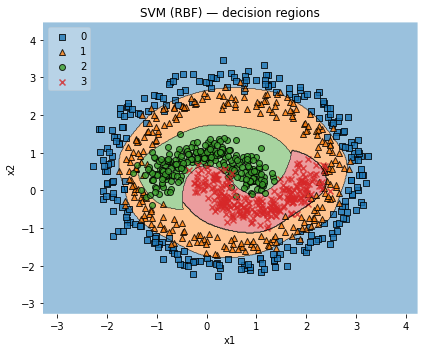

In [13]:
svm_final = SVC(kernel="rbf", C=5.0, gamma=1.0, decision_function_shape="ovr", random_state=42)
svm_final.fit(X_train, y_train)

print_metrics("SVM (rbf, C=5, gamma=1.0)", svm_final, X_test, y_test)
plot_decisions(points, labels, svm_final, "SVM (RBF) — decision regions")

=== GradientBoosting ===
Accuracy : 0.9050
Precision: 0.9073
Recall   : 0.9050
F1-score : 0.9054



c:\Users\danit\anaconda3\envs\ml-course\lib\site-packages\mlxtend\plotting\decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


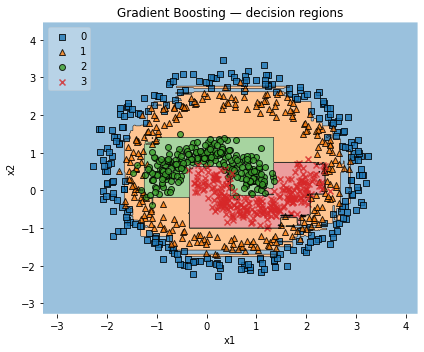

In [14]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    random_state=42
)
gb.fit(X_train, y_train)

print_metrics("GradientBoosting", gb, X_test, y_test)
plot_decisions(points, labels, gb, "Gradient Boosting — decision regions")

В данной задаче ожидаемо лучше показал себя метод SVM, так как его возможность использовать ядра, порождающие области с гладкой границей (такие как RBF), позволяют лучше описать форму данного датасета, где в особенности представлены окружности и полумесяцы.